In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

houses=pd.read_excel("C:\Python for data analytics\Machine Learning\Group assignment\Houses for rent in Madrid.xlsx")
houses.head()

<>:7: SyntaxWarning: invalid escape sequence '\P'
<>:7: SyntaxWarning: invalid escape sequence '\P'
C:\Users\vldma\AppData\Local\Temp\ipykernel_8660\870881630.py:7: SyntaxWarning: invalid escape sequence '\P'
  houses=pd.read_excel("C:\Python for data analytics\Machine Learning\Group assignment\Houses for rent in Madrid.xlsx")


,Id,District,Address,Number,Area,Rent,Bedrooms,Sq.Mt,Floor,Outer,Elevator,Penthouse,Cottage,Duplex,Semidetached
0,1,Ciudad Lineal,Piso en Quintana,NaN,Quintana,1300,2.0,72,3.0,1.0,1.0,0,0,0,0
1,2,Ciudad Lineal,Piso en calle de Arturo Soria,NaN,Costillares,3000,5.0,260,2.0,1.0,1.0,0,0,0,0
2,3,Ciudad Lineal,Piso en calle de Vicente Muzas,4,Colina,1300,2.0,100,3.0,1.0,1.0,0,0,0,0
3,4,Ciudad Lineal,Piso en calle Badajoz,NaN,San Pascual,1600,3.0,120,4.0,1.0,1.0,0,0,0,0
4,5,Ciudad Lineal,Piso en calle de Nuestra Señora del Villar,9,Ventas,800,2.0,60,3.0,1.0,0.0,0,0,0,0


In [150]:
houses.columns=houses.columns.str.lower().str.strip().str.replace(' ', '_')

In [190]:
predictors = [
    'Sq.Mt',
    'Rent',
    'Floor',
    'Outer',
    'Elevator',
    'Penthouse',
    'Cottage',
    'Duplex',
    'Semidetached'
]

In [191]:
import statsmodels.api as sm

df_test = houses.copy()

df_test["Bedrooms_missing"] = df_test["Bedrooms"].isna().astype(int)

predictors = [
    'Sq.Mt',
    'Rent',
    'Floor',
    'Outer',
    'Elevator',
    'Penthouse',
    'Cottage',
    'Duplex',
    'Semidetached'
]

data = df_test[["Bedrooms_missing"] + predictors].dropna()

y = data["Bedrooms_missing"]
X = sm.add_constant(data[predictors])

model = sm.Logit(y, X).fit()
print(model.summary())

         Current function value: 0.119439
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:       Bedrooms_missing   No. Observations:                 1906
Model:                          Logit   Df Residuals:                     1896
Method:                           MLE   Df Model:                            9
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.3561
Time:                        10:52:49   Log-Likelihood:                -227.65
converged:                      False   LL-Null:                       -353.54
Covariance Type:            nonrobust   LLR p-value:                 4.203e-49
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.6695      0.552      4.832      0.000       1.587       3.752
Sq.Mt           -0.0941      0.010     -9.045      0.000   

C:\Users\vldma\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Numeric columns (11): ['id', 'rent', 'bedrooms', 'sq.mt', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']
Categorical columns (4): ['district', 'address', 'number', 'area']


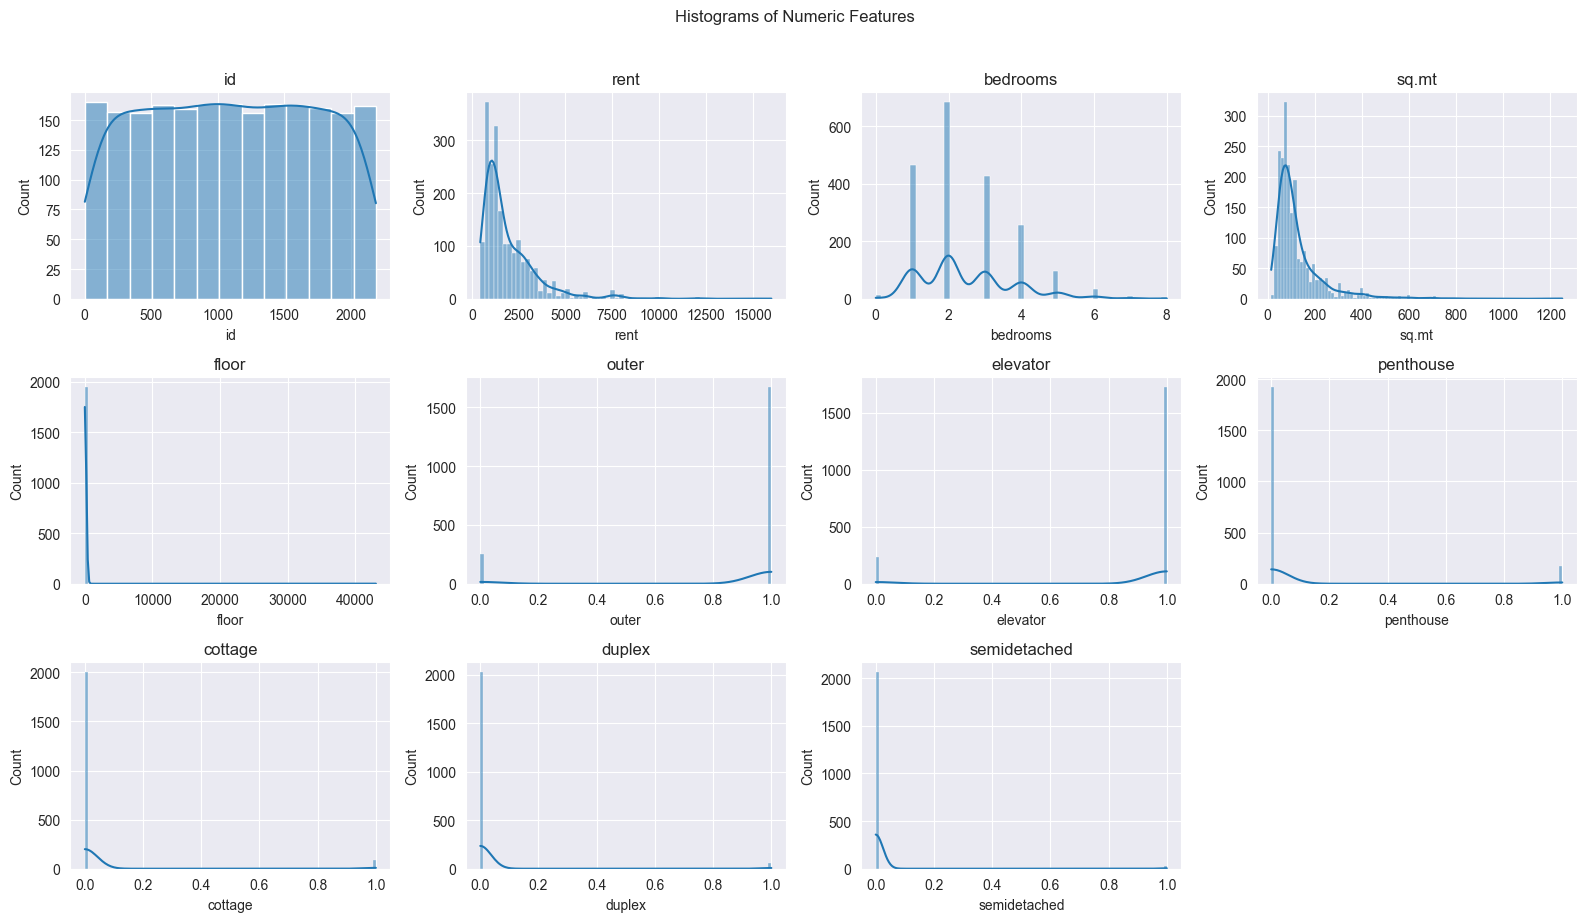

In [151]:
numeric_cols = houses.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = houses.select_dtypes(include=['object','category']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)
n_num = len(numeric_cols)
if n_num:
    n_cols = 4
    n_rows = int(np.ceil(n_num / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows))
    axes = axes.flatten()
    for i, col in enumerate(numeric_cols):
        ax = axes[i]
        sns.histplot(houses[col].dropna(), kde=True, ax=ax, color="#1f77b4")
        ax.set_title(col)
    # Hide extra axes
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    fig.suptitle('Histograms of Numeric Features', y=1.02)
    plt.tight_layout()
    plt.show()

First we start with the validation to ensure there is no data leakage. Splitting in train and test will be done in a 80/20 percentage, 80% training and 20% testing.

In [152]:
from sklearn.model_selection import train_test_split

df_model, df_reserved = train_test_split(houses, test_size=0.2, random_state=42)
print ("Sample size dataset reserved for prediction: ", df_reserved.shape[0], "records")

Sample size dataset reserved for prediction:  418 records


In [153]:
target = 'rent'

X_train, X_test, y_train, y_test = train_test_split(
    df_model.drop(columns=[target]),
    df_model[target],
    test_size=0.2,
    random_state=42
)

print ("Sample size train dataset: ", X_train.shape)
print ("Sample size test dataset: ", X_test.shape)

Sample size train dataset:  (1336, 14)
Sample size test dataset:  (335, 14)


In [154]:
X_train.head()

,id,district,address,number,area,bedrooms,sq.mt,floor,outer,elevator,penthouse,cottage,duplex,semidetached
1669,1743,Chamberí,Piso en calle de Fernández de la Hoz,NaN,Almagro,2.0,153,6.0,1.0,1.0,0,0,0,0
310,326,Hortaleza,Piso en calle Vicente Morales,NaN,Conde Orgaz-Piovera,2.0,117,1.0,1.0,1.0,0,0,0,0
807,851,Salamanca,Dúplex en serrano,NaN,Recoletos,2.0,225,4.0,1.0,1.0,0,0,1,0
1688,1764,Chamberí,Ático en Trafalgar,NaN,en Trafalgar,3.0,225,6.0,1.0,1.0,1,0,0,0
1595,1667,Chamartín,Piso en calle Núñez Morgado,4,Castilla,1.0,85,1.0,1.0,1.0,0,0,0,0


In [155]:
Total=X_train.isna().sum()
Percent=Total/X_train.shape[0]*100
missing_data=pd.DataFrame({'Total':Total,'Percent':Percent})
missing_data.sort_values(by='Percent',ascending=False)

,Total,Percent
number,863,64.595808
outer,103,7.709581
floor,92,6.886228
elevator,79,5.913174
bedrooms,54,4.041916
area,4,0.299401
address,0,0.000000
district,0,0.000000
id,0,0.000000
sq.mt,0,0.000000


According to the table above, we have detected that column "number" has an overwhelming 64.59% missing values, thus we have decided to drop this column. The columns "outer", "floor","elevator","bedrooms", and "area" have a small percentage of missing values and we will not apply any remedies.

Short MCAR section because if the missing values are not missing at random, WE CANNOT IMPUTE ANYTHING, NOT REMEDIES TO BE APPLIED.

AttributeError: module 'pingouin' has no attribute 'missing_little'

In [156]:
X_train.drop(columns=['number','id'], inplace=True)
X_test.drop(columns=['number','id'], inplace=True)

Now we will one-hot encode the variable "area". We will also transform the text to lowercase and will have ONLY the name of the area. Since these variables are prone to multicolinearity we will identify the most common area and we will drop it to avoid the dummy variable trap. In our case Recoletos is the most common area, thus it will become our control group

In [157]:
X_train['area']=X_train['area'].str.lower().str.strip()
X_test['area']=X_train['area'].str.lower().str.strip()

In [158]:
p= "en"
X_train["area"]=X_train["area"].str.replace(f'^{p}\s+', '', regex=True)
X_train["test"]=X_train["area"].str.replace(f'^{p}\s+', '', regex=True)
X_train["area"]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\vldma\AppData\Local\Temp\ipykernel_8660\74298206.py:2: SyntaxWarning: invalid escape sequence '\s'
  X_train["area"]=X_train["area"].str.replace(f'^{p}\s+', '', regex=True)
C:\Users\vldma\AppData\Local\Temp\ipykernel_8660\74298206.py:3: SyntaxWarning: invalid escape sequence '\s'
  X_train["test"]=X_train["area"].str.replace(f'^{p}\s+', '', regex=True)


1669                almagro
310     conde orgaz-piovera
807               recoletos
1688              trafalgar
1595               castilla
               ...         
1092                    sol
1894             berruguete
1875      cuzco-castillejos
663                 adelfas
957               recoletos
Name: area, Length: 1336, dtype: object

In [159]:

area_cat_1hot=pd.get_dummies(X_train['area'], prefix="")
X_train=pd.concat([X_train,area_cat_1hot],axis=1)
areas_cat_1hot=pd.get_dummies(X_test['area'], prefix="")
X_test=pd.concat([X_test,area_cat_1hot],axis=1)
X_train.head()

,district,address,area,bedrooms,sq.mt,floor,outer,elevator,penthouse,cottage,...,_valdebernardo - valderribas,_valdemarín,_valdezarza,_vallehermoso,_ventas,_ventilla-almenara,_vinateros,_vista alegre,_zofá­o,_águilas
1669,Chamberí,Piso en calle de Fernández de la Hoz,almagro,2.0,153,6.0,1.0,1.0,0,0,...,False,False,False,False,False,False,False,False,False,False
310,Hortaleza,Piso en calle Vicente Morales,conde orgaz-piovera,2.0,117,1.0,1.0,1.0,0,0,...,False,False,False,False,False,False,False,False,False,False
807,Salamanca,Dúplex en serrano,recoletos,2.0,225,4.0,1.0,1.0,0,0,...,False,False,False,False,False,False,False,False,False,False
1688,Chamberí,Ático en Trafalgar,trafalgar,3.0,225,6.0,1.0,1.0,1,0,...,False,False,False,False,False,False,False,False,False,False
1595,Chamartín,Piso en calle Núñez Morgado,castilla,1.0,85,1.0,1.0,1.0,0,0,...,False,False,False,False,False,False,False,False,False,False


In [160]:
X_train.drop(columns=['area','_recoletos'], inplace=True)
X_test.drop(columns=['area','_recoletos'], inplace=True)

The area and district variables explain roughly the same information, therefore we will be dropping district.

In [161]:
X_train.drop(columns=['district'], inplace=True)
X_test.drop(columns=['district'], inplace=True)

Now a correlation matrix will be plotted to identify the correlation between the variables and to detect any anormality.

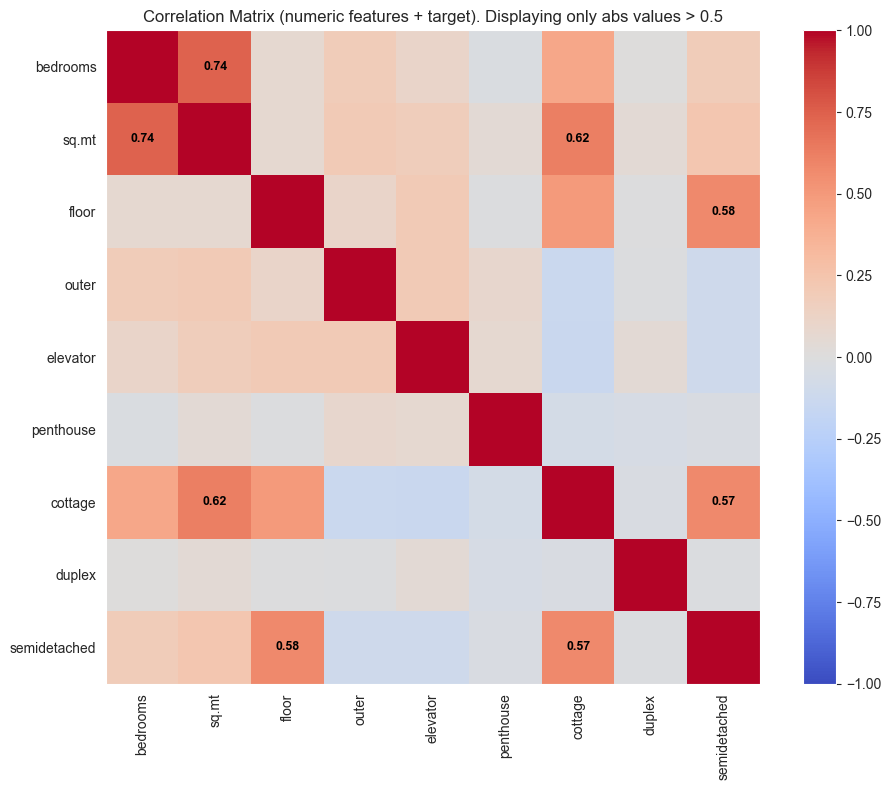

In [162]:
num_pred = [c for c in X_train.select_dtypes(include=[np.number]).columns]
corr = X_train[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}',
                    ha='center', va='center',
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix (numeric features + target). Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

Here we see that number of bedrooms is highly correlated with the sq.mt variable, which is logical since the more bedrooms a house has the bigger the more square meters it will have.

In [163]:
X_train.drop(columns=["sq.mt"], inplace= True)
X_test.drop(columns=["sq.mt"], inplace=True)

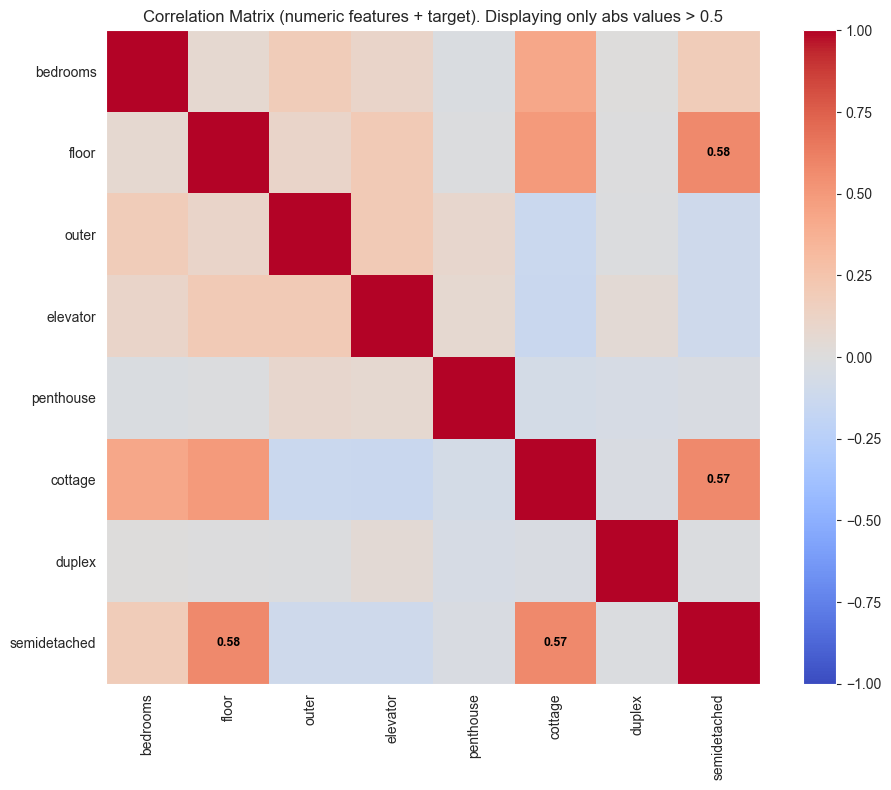

In [164]:
num_pred = [c for c in X_train.select_dtypes(include=[np.number]).columns]
corr = X_train[num_pred].corr()

fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        if abs(valor) >= 0.5 and i != j:
            ax.text(j, i, f'{valor:.2f}',
                    ha='center', va='center',
                    color='white' if abs(valor) > 0.8 else 'black',
                    fontsize=9, fontweight='bold')

ax.grid(False)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
plt.colorbar(cax)
ax.set_title('Correlation Matrix (numeric features + target). Displaying only abs values > 0.5')
plt.tight_layout()
plt.show()

Now we can see moderate correlation, low enough to proceed with the linear regression.

In [165]:
X_vif = X_train[num_pred].dropna()

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print("Variance Inflation Factors:\n")
vif_data

Variance Inflation Factors:



,Variable,VIF
3,elevator,7.337198
2,outer,7.261692
0,bedrooms,4.792806
5,cottage,3.045175
7,semidetached,3.001205
1,floor,2.803893
4,penthouse,1.174421
6,duplex,1.033079


As per the variance inflator factor, all the remaining variables have a coefficient under 10, which suggests that no variable should be removed if the criteria is not stringent. If the threshold is exigent and set at 5, only 2 variables should eb removed.

In [166]:
def remove_vif(df, thresh=10.0):
    df_actual = df.copy()

    while True:
        vif_data = pd.DataFrame()
        vif_data["Variable"] = df_actual.columns
        vif_data["VIF"] = [variance_inflation_factor(df_actual.values, i)
                           for i in range(df_actual.shape[1])]

        max_vif = vif_data["VIF"].max()

        if max_vif > thresh:
            variable_to_remove = vif_data.sort_values("VIF", ascending=False).iloc[0]["Variable"]
            print(f"Removing '{variable_to_remove}' with VIF: {max_vif:.2f}")
            df_actual = df_actual.drop(columns=[variable_to_remove])
        else:
            break

    return df_actual

X_aftervif = remove_vif(X_vif, thresh=10.0)

print("\nFinal set of variables:")
print(X_aftervif.columns.tolist())


Final set of variables:
['bedrooms', 'floor', 'outer', 'elevator', 'penthouse', 'cottage', 'duplex', 'semidetached']


In [167]:
import statsmodels.api as sm

X = sm.add_constant(X_aftervif)
model = sm.OLS(y_train_aligned, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.349
Model:                            OLS   Adj. R-squared:                  0.345
Method:                 Least Squares   F-statistic:                     77.74
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          1.04e-102
Time:                        08:52:32   Log-Likelihood:                -9818.1
No. Observations:                1169   AIC:                         1.965e+04
Df Residuals:                    1160   BIC:                         1.970e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         -247.7156    130.144     -1.903   

In [168]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

base_model = LinearRegression()

rfecv = RFECV( # RFE implemented with cross validation (RFECV)
    estimator=base_model,
    step=1, # step=1 means it removes one variable in each iteration
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error'
)

In [169]:
print("X_aftervif:", X_aftervif.shape)
print("y_train:", y_train.shape)
print("X_aftervif index unique?", X_aftervif.index.is_unique)
print("y_train index unique?", y_train.index.is_unique)

X_aftervif: (1169, 8)
y_train: (1336,)
X_aftervif index unique? True
y_train index unique? True


In [170]:
pipeline_rfe = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', rfecv),
    ('regressor', base_model)
])



In [171]:
y_train_aligned = y_train.loc[X_aftervif.index]
pipeline_rfe.fit(X_aftervif, y_train_aligned)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection

In [172]:
# We first get the real names of the selected features
feature_names = X_aftervif.columns
selected_features = feature_names[rfecv.support_].tolist()

# Then extract results from the pipeline, accessing the internal 'regressor' which was trained ONLY on selected features
optimized_model = pipeline_rfe.named_steps['regressor']
betas = optimized_model.coef_
intercept = optimized_model.intercept_

In [173]:
rfecv_detector = pipeline_rfe.named_steps['feature_selection']

ranking_df = pd.DataFrame({
    'Feature': X_aftervif.columns,
    'Ranking': rfecv_detector.ranking_,
    'Selected': rfecv_detector.support_
})

ranking_df = ranking_df.sort_values(by='Ranking')
print(ranking_df.to_string(index=False))

     Feature  Ranking  Selected
    bedrooms        1      True
       floor        1      True
    elevator        1      True
   penthouse        1      True
      duplex        2     False
semidetached        3     False
     cottage        4     False
       outer        5     False


In [175]:
import pandas as pd
import statsmodels.api as sm

# 1) Use the fitted objects INSIDE the pipeline
scaler = pipeline_rfe.named_steps['scaler']
rfecv_fitted = pipeline_rfe.named_steps['feature_selection']

# 2) Align y to X_aftervif rows (critical)
y_train_aligned = y_train.loc[X_aftervif.index]

# 3) Scale X and select the RFECV-chosen features
X_scaled = scaler.transform(X_aftervif)
X_selected_scaled = X_scaled[:, rfecv_fitted.support_]

# 4) Build a DataFrame with the CORRECT index (same rows as X_aftervif)
X_stat = pd.DataFrame(
    X_selected_scaled,
    columns=selected_features,
    index=X_aftervif.index
)

# 5) Fit statsmodels OLS
X_stat_with_const = sm.add_constant(X_stat)
ols_stats = sm.OLS(y_train_aligned, X_stat_with_const).fit()

# 6) Extract results from statsmodels (no need for separate betas/intercept vars)
intercept = ols_stats.params['const']
betas = ols_stats.params.drop('const')

results_summary = pd.DataFrame({
    'Variable': betas.index,
    'Beta': betas.values,
    'p-value': ols_stats.pvalues.drop('const').values
}).sort_values(by='p-value')

print(f"Model Intercept: {intercept:.2f}")
print(f"R-squared (train/in-sample): {ols_stats.rsquared:.3f}")

format_pvi = {'Beta': '{:.2f}'.format, 'p-value': '{:.3f}'.format}
print("-" * 45)
print(results_summary.to_string(index=False, formatters=format_pvi))
print("-" * 45)

Model Intercept: 1849.26
R-squared (train/in-sample): 0.348
---------------------------------------------
 Variable   Beta p-value
 bedrooms 716.23   0.000
penthouse 168.99   0.000
 elevator 163.99   0.000
    floor  89.45   0.007
---------------------------------------------


In [177]:
import statsmodels.api as sm

def backward_elimination(X, y, threshold=0.05):
    # --- ensure perfect alignment for statsmodels ---
    y = y.loc[X.index]

    features = list(X.columns)
    while len(features) > 0:
        X_with_const = sm.add_constant(X[features])
        model = sm.OLS(y, X_with_const).fit()

        p_values = model.pvalues.drop('const')
        max_p_value = p_values.max()

        if max_p_value > threshold:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
            print(f"Removing '{excluded_feature}' with p-value: {max_p_value:.4f}")
        else:
            break

    return model, features


rfecv_fitted = pipeline_rfe.named_steps["feature_selection"]


X_rfe = X_aftervif.loc[:, rfecv_fitted.support_]

final_model, final_features = backward_elimination(X_rfe, y_train)

X_final = X_aftervif.loc[:, final_features]

print("\n" + "="*78)
print("FINAL MODEL with only relevant variables")
print("="*78)
print(final_model.summary())


FINAL MODEL with only relevant variables
                            OLS Regression Results                            
Dep. Variable:                   rent   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.346
Method:                 Least Squares   F-statistic:                     155.5
Date:                Tue, 24 Feb 2026   Prob (F-statistic):          1.26e-106
Time:                        10:26:46   Log-Likelihood:                -9818.8
No. Observations:                1169   AIC:                         1.965e+04
Df Residuals:                    1164   BIC:                         1.967e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const     